# Projet 8 — Scoring crédit : analyse & récapitulatif du projet

Ce notebook a deux objectifs :
1. **Exploration des données** (EDA) — comprendre le dataset Home Credit Default Risk sur lequel le modèle est entraîné.
2. **Récit du projet** — les choix techniques faits tout au long du développement (modèle, API, stockage, explicabilité, monitoring), et pourquoi.

*Notebook généré avec l'assistance de Claude (Anthropic), en accompagnement du développement du projet.*

## 1. Exploration des données (EDA)

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

### 1.1 Chargement et vue d'ensemble

`df_final_clean.parquet` est le résultat du feature engineering (agrégation des tables `bureau`, `previous_application`, `POS_CASH_balance`, etc. du dataset Home Credit — travail réalisé en amont de ce projet). On charge ici exactement ce que voit le modèle à l'entraînement (`preprocessing.clean_col_names` + `downcast_floats`, identique à `config.py`).

In [2]:
from preprocessing import clean_col_names, downcast_floats

df = pd.read_parquet("df_final_clean.parquet")
df = clean_col_names(df)
df = downcast_floats(df)

print(f"Shape : {df.shape[0]:,} lignes x {df.shape[1]:,} colonnes")
df.head()

Shape : 307,511 lignes x 1,265 colonnes


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,AMT_DOWN_PAYMENT_was_missing_min,RATE_DOWN_PAYMENT_was_missing_mean,RATE_DOWN_PAYMENT_was_missing_max,RATE_DOWN_PAYMENT_was_missing_min,AMT_ANNUITY_was_missing_mean_y,AMT_ANNUITY_was_missing_max_y,AMT_ANNUITY_was_missing_min_y,CNT_PAYMENT_was_missing_mean,CNT_PAYMENT_was_missing_max,CNT_PAYMENT_was_missing_min,AMT_GOODS_PRICE_was_missing_mean,AMT_GOODS_PRICE_was_missing_max,AMT_GOODS_PRICE_was_missing_min,HAS_CREDIT_CARD,HAS_POS_CASH
0,100002,1,0,1.0,0,1,0,202500.0,406597.5,24700.5,351000.0,1,0.018801,-9461,-637,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,1,1
1,100003,0,0,0.0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,3,0.003541,-16765,-1188,...,0.0,0.333333,1.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,1,1
2,100004,0,1,1.0,1,1,0,67500.0,135000.0,6750.0,135000.0,1,0.010032,-19046,-225,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,1,1
3,100006,0,0,0.0,0,1,0,135000.0,312682.5,29686.5,297000.0,1,0.008019,-19005,-3039,...,0.0,0.777778,1.0,0.0,0.333333,1.0,0.0,0.333333,1.0,0.0,0.333333,1.0,0.0,1,1
4,100007,0,0,1.0,0,1,0,121500.0,513000.0,21865.5,513000.0,1,0.028663,-19932,-3038,...,0.0,0.666667,1.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,1,1


### 1.2 Déséquilibre de la cible

`TARGET` = 1 si le client a fait défaut sur son crédit, 0 sinon. Un déséquilibre fort justifie les deux choix faits dans `model.py` : pas de rééquilibrage à l'entraînement (`scale_pos_weight=1`), mais un **seuil de décision optimisé sur un coût métier** plutôt que le seuil par défaut de 0.5 (voir section 2.1).

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


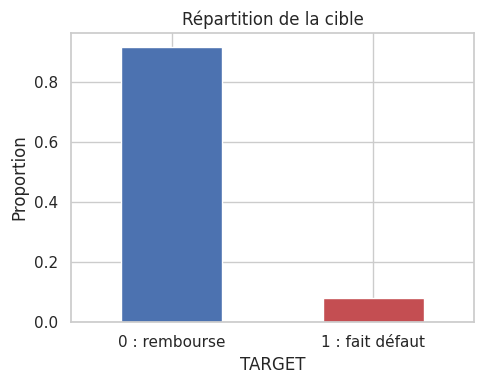

In [3]:
repartition = df["TARGET"].value_counts(normalize=True).sort_index()
print(repartition)

fig, ax = plt.subplots(figsize=(5, 4))
repartition.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["0 : rembourse", "1 : fait défaut"], rotation=0)
ax.set_ylabel("Proportion")
ax.set_title("Répartition de la cible")
plt.tight_layout()
plt.show()

### 1.3 Gestion des valeurs manquantes

Fait notable : **0 valeur manquante** dans les 1265 colonnes de ce fichier — mais ce n'est pas parce que les données sources n'en avaient pas. Le feature engineering amont a imputé les valeurs manquantes et conservé l'information via des colonnes indicatrices `*_was_missing` (174 au total). Ci-dessous, les taux de "était manquant à l'origine" les plus élevés — c'est la vraie mesure de complétude des données sources ; `df.isna().mean()` ne montrerait plus rien à ce stade du pipeline.

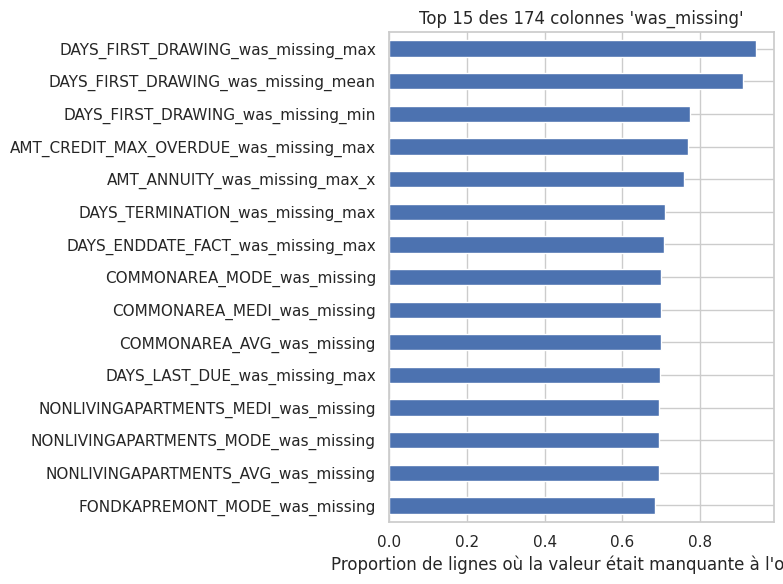

In [4]:
assert df.isna().sum().sum() == 0, "0 valeur manquante attendue à ce stade du pipeline"

colonnes_was_missing = [c for c in df.columns if "was_missing" in c]
taux_manquant_origine = df[colonnes_was_missing].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
taux_manquant_origine.plot(kind="barh", ax=ax)
ax.set_xlabel("Proportion de lignes où la valeur était manquante à l'origine")
ax.set_title(f"Top 15 des {len(colonnes_was_missing)} colonnes 'was_missing'")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 1.4 Distributions des variables les plus influentes

On regarde ici les colonnes qui pèsent le plus sur les décisions du modèle (`monitoring.FEATURES_MONITOREES`, voir section 2.5), découpées par `TARGET` pour voir si leur distribution diffère selon le remboursement ou non.

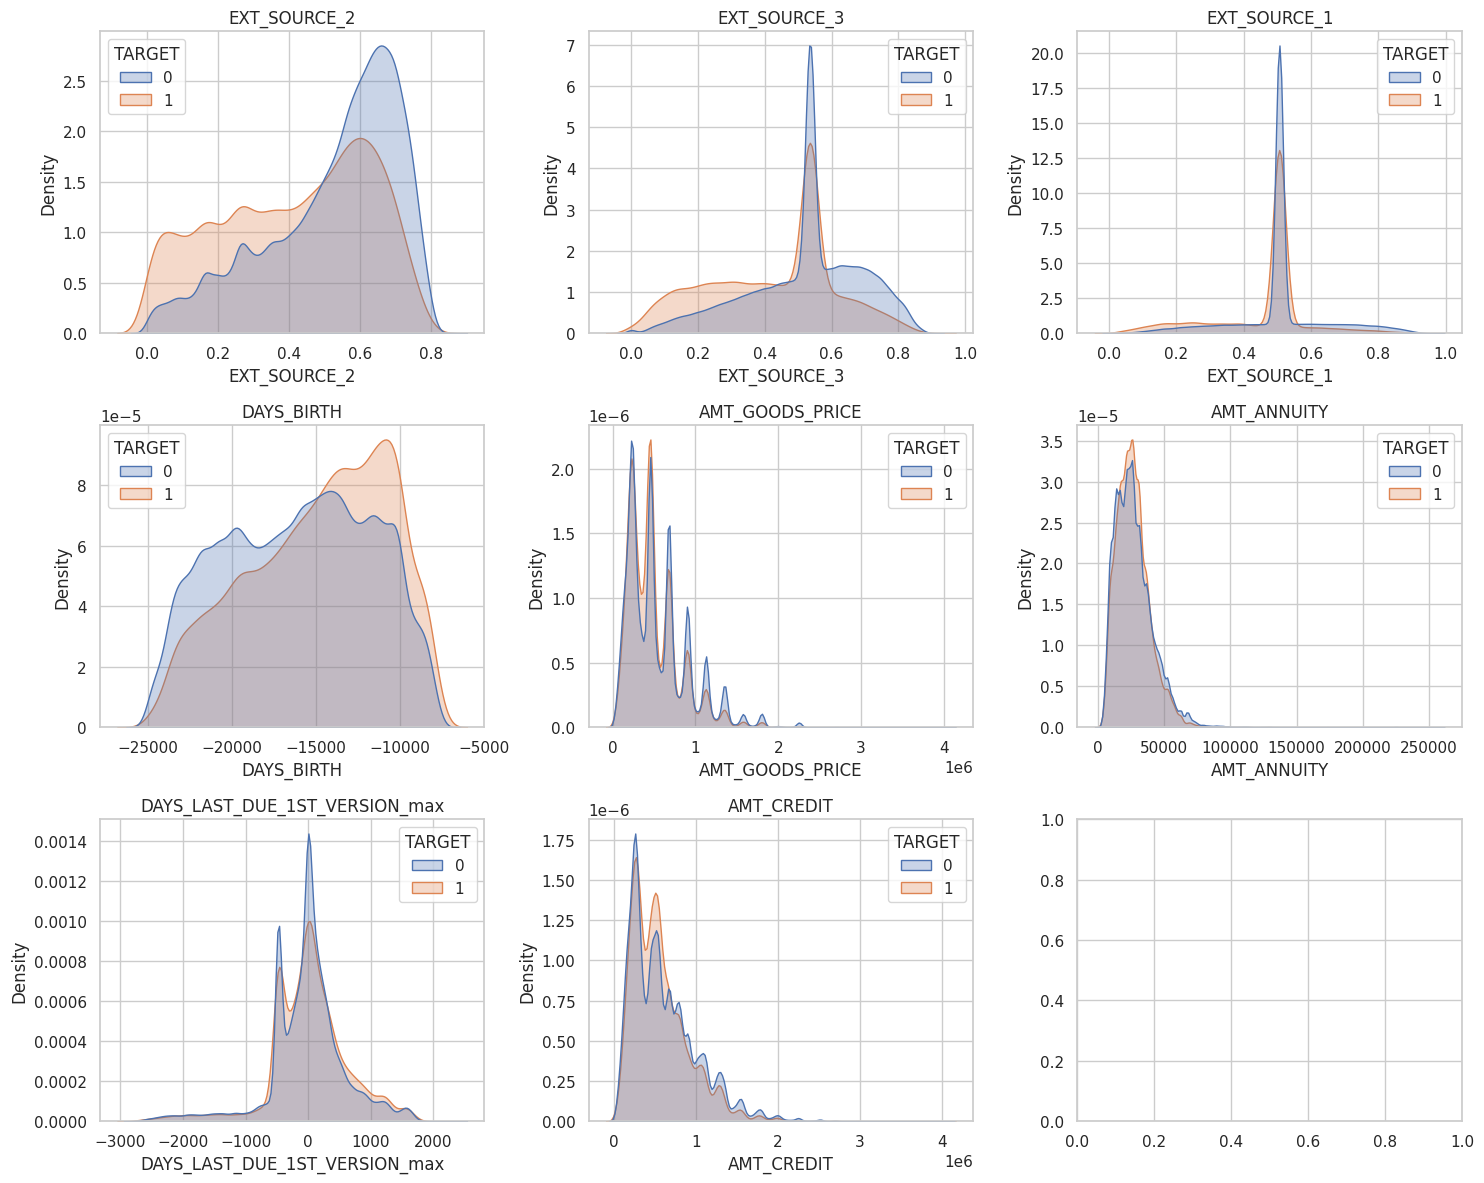

In [ ]:
from monitoring import FEATURES_MONITOREES
import math

numeriques = [c for c in FEATURES_MONITOREES if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique() > 10]

cols = 3
rows = math.ceil(len(numeriques) / cols) # =3
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flat
for ax, colonne in zip(axes, numeriques):
    sns.kdeplot(data=df, x=colonne, hue="TARGET", ax=ax, common_norm=False, fill=True, alpha=0.3)
    ax.set_title(colonne)
for ax in list(axes)[len(numeriques):]:
    ax.axis("off")
plt.title("Histogramme des features par feature et par TARGET")
plt.tight_layout()
plt.show()

### 1.5 Importance des variables (modèle entraîné)

Importance globale calculée directement sur le modèle CatBoost entraîné (`model.pkl`), le vrai classement utilisé pour choisir `FEATURES_MONITOREES` dans `monitoring.py`.

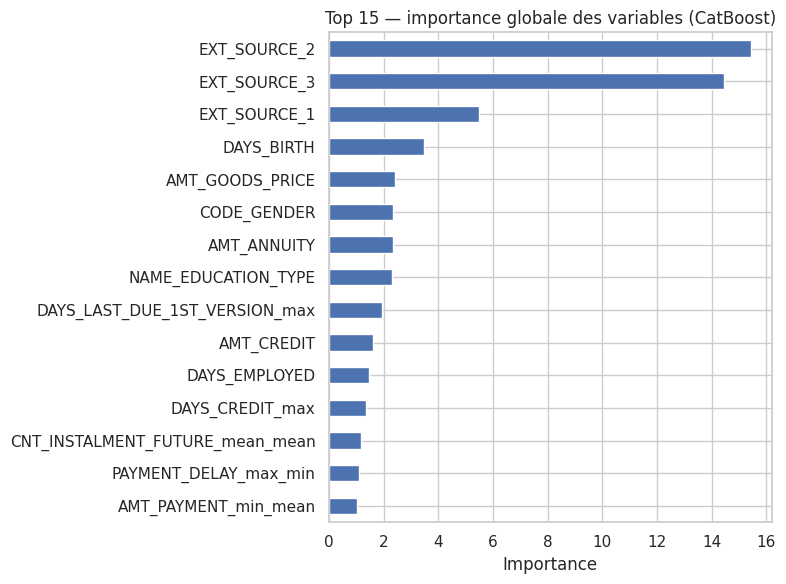

F1 score (test, à l'entraînement) : 0.300
Seuil de décision optimal (stocké dans model.pkl) : 0.09 (vs 0.5 par défaut)


In [6]:
import joblib

pipeline, seuil_optimal, score_f1 = joblib.load("model.pkl")
modele = pipeline.named_steps["model"]

importances = pd.Series(modele.get_feature_importance(), index=modele.feature_names_)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 — importance globale des variables (CatBoost)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"F1 score (test, à l'entraînement) : {score_f1:.3f}")
print(f"Seuil de décision optimal (stocké dans model.pkl) : {seuil_optimal:.2f} (vs 0.5 par défaut)")

## 2. Étude du modèle et justification de choix techniques

### 2.1 Modèle et seuil de décision métier

`CatBoostClassifier` (200 itérations, depth 6), entraîné sans rééquilibrage de classes. Le rééquilibrage est géré différemment : en **coût métier post-hoc**, pas au niveau du modèle. `model.py::chercher_seuil_optimal` teste des seuils de 0.05 à 0.95 et choisit celui qui minimise :

`coût = 10 × (faux négatifs) + 1 × (faux positifs)`

Un faux négatif (rater un client à risque) coûte 10x plus qu'un faux positif (fausse alerte sur un bon client).

*Note : le graphique ci-dessous est recalculé sur l'ensemble complet des données (pas uniquement le jeu de test utilisé à l'entraînement), à titre illustratif du principe. Le seuil en pointillé rouge est bien celui réellement stocké dans `model.pkl`, pas recalculé ici.*

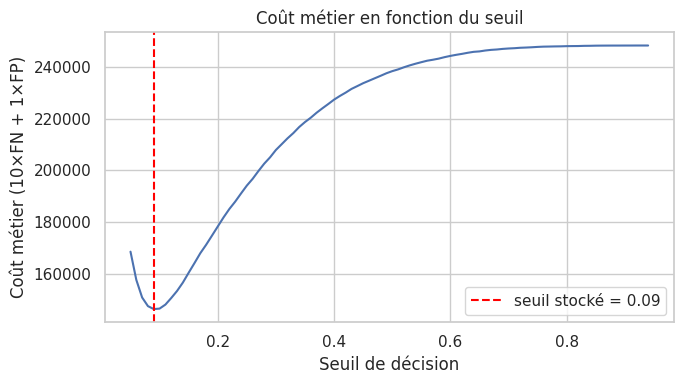

In [7]:
from model import cout_metier

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

proba = pipeline.predict_proba(X)[:, 1]

seuils = np.arange(0.05, 0.95, 0.01)
couts = [cout_metier(y.values, proba, s) for s in seuils]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(seuils, couts)
ax.axvline(seuil_optimal, color="red", linestyle="--", label=f"seuil stocké = {seuil_optimal:.2f}")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Coût métier (10×FN + 1×FP)")
ax.set_title("Coût métier en fonction du seuil")
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Architecture de l'API

FastAPI + une démo Gradio montée en sous-route (`/demo`).

Routes principales :
- `POST /predict/{customer_id}` — protégée par clé API (header `X-API-Key`)
- `GET /demo` — démo Gradio publique, sans authentification
- `GET /docs` — documentation Swagger auto-générée par FastAPI

### 2.3 Stockage et versioning du modèle

Le projet a exploré une architecture "modèle externalisé" (MinIO/S3 avec versioning automatique — voir `minio_client.py`, branche dédiée) : chaque entraînement génère une copie horodatée immuable + un alias `model.pkl` mis à jour, permettant de changer de modèle sans reconstruire l'image Docker.

Nous avons eu quelques complications pour loader le model.pkl dans HuggingFace.
Pour la version actuelle, choix assumé de revenir à un modèle **baké dans l'image** (`COPY model.pkl` dans le `Dockerfile`) : plus simple à déployer, zéro dépendance réseau au démarrage — pertinent vu la taille modeste du modèle (~330 Ko). Le code du flux externalisé reste en place et documenté (`README.md`, section "Déploiement en production") pour le jour où ça redevient utile.

### 2.4 Explicabilité — pourquoi telle prédiction ?

Au-delà de la prédiction, l'API expose les variables qui ont le plus pesé sur **cette prédiction précise** (pas l'importance globale du modèle) — via les valeurs de Shapley, calculées nativement par CatBoost (pas besoin de la librairie `shap`). Deux listes de colonnes candidates selon le besoin :
- `FEATURES_MONITOREES` (`monitoring.py`) : top 10 par importance globale — sert au monitoring/drift (section 2.5), inclut des scores opaques (`EXT_SOURCE_*`).
- `FEATURES_INTERPRETABLES` (branche `feature/improve_api`) : uniquement des colonnes compréhensibles sans expertise data (revenu, montant du crédit...) — utilisée pour l'explication affichée à l'utilisateur et le formulaire de simulation "what-if".

Démonstration ci-dessous (calcul réel sur un client du dataset, pas une valeur figée).

In [8]:
from catboost import Pool

client_exemple = X.iloc[[0]]
shap_values = modele.get_feature_importance(Pool(client_exemple), type="ShapValues")[0]
contributions = pd.Series(shap_values[:-1], index=client_exemple.columns)  # dernière valeur = biais du modèle

top3 = contributions.abs().sort_values(ascending=False).head(3)
for colonne in top3.index:
    signe = "+" if contributions[colonne] > 0 else "-"
    print(f"{colonne:30s} contribution {signe}{abs(contributions[colonne]):.3f} (valeur = {client_exemple[colonne].values[0]})")

EXT_SOURCE_3                   contribution +0.815 (valeur = 0.13937577605247498)
EXT_SOURCE_1                   contribution +0.614 (valeur = 0.08303696662187576)
EXT_SOURCE_2                   contribution +0.366 (valeur = 0.262948602437973)


### 2.5 Monitoring en production

Chaque prédiction loggue dans `predictions.db` (SQLite en dev, `DATABASE_URL` externe en prod sans changement de code) :
- les valeurs des colonnes `FEATURES_MONITOREES` au moment de la prédiction,
- le temps d'exécution (`duree_ms`).

Deux scripts d'analyse séparés :
- `analyse_drift.py` — compare les inputs loggués à la distribution d'entraînement (distance de Wasserstein pour le numérique, Jensen-Shannon pour le catégoriel, via `evidently`). Tourne dans un venv **Python 3.12 dédié** (`evidently` incompatible avec le Python 3.14 du projet — dépendance à `pydantic.v1`, retirée en 3.14).
- `analyse_operationnel.py` — latence (moyenne/P95/P99, anomalies) et taux d'erreur (table `error_events`, erreurs serveur 500 uniquement). Pas de dépendance particulière.

Commandes complètes : voir `GUIDE_LOCAL.md`.

### 2.6 Tests et CI/CD

`pytest` (11 tests) couvre : authentification (clé API absente/invalide), prédictions sur ID connu/inconnu/invalide, non-régression sur `get_customer`/`log_prediction`. Un fixture réduit (`tests/fixtures/sample_customers.parquet`) évite de dépendre du dataset complet (275 Mo, non versionné) en CI.

**État actuel** : le pipeline CI/CD (GitHub Actions — tests automatiques, build Docker, publication) est écrit (`.github/workflows/ci-cd.yml`) mais pas encore vérifié en conditions réelles sur GitHub — prochaine étape du projet.

## 3. Bilan et prochaines étapes

Ce qui fonctionne et est vérifié de bout en bout : API, tests, Docker, monitoring (drift + opérationnel), explicabilité par prédiction.

Reste à faire : vérifier le pipeline CI/CD en conditions réelles, valider le déploiement public (bloqué actuellement par le passage du SDK Docker de Hugging Face Spaces en payant), et accumuler assez de vraies prédictions en production pour que l'analyse de drift devienne statistiquement significative.